# STEP 0: IMPORT MODULES

Run this code block once per session, to initialise and import modules.

In [1]:
import hff_analysis
import pathlib

# STEP 1: READ ADICHT FILE INTO PYTHON

This block only needs to be run once for each file being read,
unless `data_segments` needs to be changed.

## Arguments
* `filename` -- name of the file to be read (extension optional).
* `data_segments` -- which recording segment(s) from the file to read.
    Define a list to read segments at those indices, or set to `None`
    to read all segments in the file.
    * The duration in seconds of each segment which is read will be
      printed to assist in identifying relevant segment(s). If
      unnecessary segments have been read in this block, they can be
      filtered out in the next step without needing to rerun this block.

In [11]:
# User defined variables
filename = 'hff11_pos2_freqsweep'
data_segments = None


### User does not need to modify below this line ###

recordings = hff_analysis.read_adicht(filename, data_segments)

[0]: 311.25 s


# STEP 2: DETECT SPIKES

This code block detects spikes and plots them. Run this block, then
tweak `threshold_uV` and/or `epoch_timing_ms` using the plots to
exclude detected peaks which are not from the target unit. Repeat as
many times as necessary before moving onto step 3.

## Arguments
* `recording_id` -- index of the recording segment to analyse.
    * Only one segment should be analysed at a time - do not specify a
      list or range!
    * Note that this index is relative to the data segment(s) chosen in
      the above step. (e.g. If `data_segments = [0, 2]` was used
      previously, then `recording_id = 1` should be used to inspect the
      third segment from the original file.)
* Spike detection controls - these variables set boundaries for spike
  detection which are applied to both mechanical and electrical
  stimulation:
    * `epoch_timing_ms` -- timing window in milliseconds relative to each
        stimulus onset during which spikes may occur, as a `tuple` of
        numeric values.
        * The first value indicates start time and the second value end
          time.
        * The conversion from milliseconds to samples is done using
          `int()`,  which always rounds down non-integer floats. Since
          the expected sample rate is high, this level of imprecision
          should not be important. However, note that it may be possible
          for floating-point imprecision to cause misalignment of the
          epochs and spikes by one sample.
    * `threshold_uV` -- threshold in microvolts above which spikes
      should be detected.
* Spike filtering criteria - this is applied after spike detection and
  limits the spikes which are collected on a per-stimulation basis:
    * `spike_criteria` -- a dictionary containing `SpikeCriteria`
      objects for each stimulation type.
* `save_figures` -- a bool for controlling whether figures are saved.
  If this is enabled, existing figures at the target path will be
  overwritten.

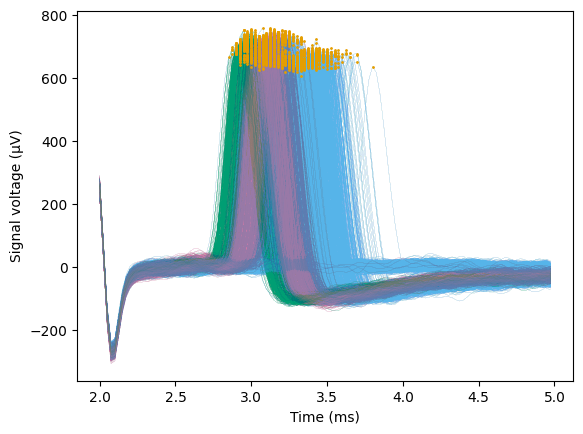

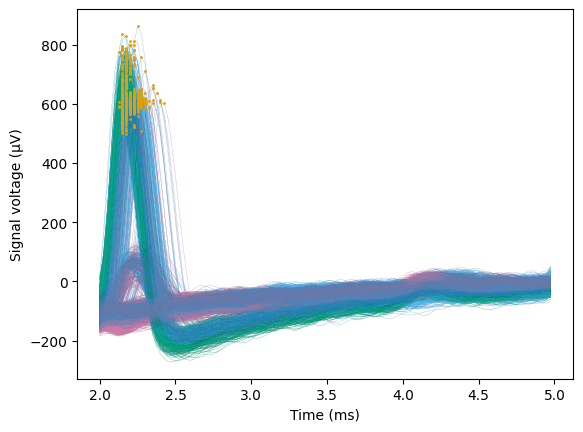

In [13]:
# User defined variables
recording_id = 0
epoch_timing_ms = (2, 5)
threshold_uV = 200
spike_criteria = {
    'mechanical': hff_analysis.SpikeCriteria(None, None, None, None),
    'electrical': hff_analysis.SpikeCriteria(None, None, None, None)
}
save_figures = True


### User does not need to modify below this line ###

try:
    recording = recordings[recording_id]
except (AttributeError, TypeError) as e:
    raise TypeError(
        "Run this block on one recording segment at a time (i.e. "
        "ensure that `recording_id` is an `int`, not a `range`)."
    ) from e
if recording.test == 'frequency':
    spikes, epochs = hff_analysis.freqsweep_spikes(
        recording,
        epoch_timing_ms,
        threshold_uV,
        spike_criteria
    )
    # elif recording.test == "amplitude":
    #     hff_analysis.ampl.analyse_amplsweep(
    #         filename,
    #         recording,
    #         threshold_uV
    #     )
    # elif recording.test == "nine-one":
    #     df_summary = hff_analysis.nine.analyse_nineone()
    # elif recording.test == "long-duration":
    #     df_summary = hff_analysis.long.analyse_longduration()

recording_segment = (data_segments[recording_id] if data_segments
                     else recording_id)
try:
    hff_analysis.plot_spikes(
        spikes,
        epochs,
        save_figures,
        filename,
        recording_segment
    )
except FileNotFoundError:
    pathlib.Path(hff_analysis.CLUSTER_PLOTS_FOLDER).mkdir(
        parents=True,
        exist_ok=True
    )
    hff_analysis.plot_spikes(
        spikes,
        epochs,
        save_figures,
        filename,
        recording_segment
    )

# STEP 3: SAVE DATA
Run this code block once after you are satisfied with the spike
detection to save your results as a JSON file. Repeat these 3 steps for
each file/recording segment that will be analysed, then move onto
`main_part2.ipynb`.

By default, if the target file already exists, the user will be asked
for manual confirmation before the file is overwritten. This behaviour
can be changed by setting `force_overwrite = True` at the start
of the code block.

In [14]:
# User defined variables
force_overwrite = False


### User does not need to modify below this line ###

hff_analysis.save_to_json(
    hff_analysis.FILEREADSETTINGS_JSON_FOLDER,
    filename,
    recording_segment,
    'FILEREADSETTINGS',
    force_overwrite,
    filename=filename,
    recording_segment=recording_segment,
    epoch_timing_ms=epoch_timing_ms,
    threshold_uV=threshold_uV,
    spike_criteria=spike_criteria
)

hff_analysis.save_to_json(
    hff_analysis.SPIKES_JSON_FOLDER,
    filename,
    recording_segment,
    'SPIKES',
    force_overwrite,
    spikes=spikes
)

hff_analysis.save_to_json(
    hff_analysis.EPOCHS_JSON_FOLDER,
    filename,
    recording_segment,
    'EPOCHS',
    force_overwrite,
    epochs=epochs
)

SUCCESS: `hff11_pos2_freqsweep-[0]-FILEREADSETTINGS.json` saved to `.\outputs\JSON\file_read_settings\`
SUCCESS: `hff11_pos2_freqsweep-[0]-SPIKES.json` saved to `.\outputs\JSON\spikes\`
SUCCESS: `hff11_pos2_freqsweep-[0]-EPOCHS.json` saved to `.\outputs\JSON\epochs\`
